In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from model import LeNet, LeNet_dropout
from train_test import train, test, early_stop

In [2]:
# hyperparameters
learning_rate = 0.005
batch_size = 32
weight_decay = 1e-4

In [3]:
# load the data
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(train_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [4]:
# pick accelerator
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'

# instantiate models into accelerator
model_regular = LeNet().to(device)
model_dropout = LeNet_dropout().to(device)

# loss function and optimizers
loss_fn = nn.CrossEntropyLoss()
optimizer_regular = torch.optim.AdamW(model_regular.parameters(), lr=learning_rate, weight_decay=weight_decay)
optimizer_dropout = torch.optim.AdamW(model_dropout.parameters(), lr=learning_rate, weight_decay=weight_decay)

epoch | train_loss | test_loss | accuracy(%)
1     |   0.0164   |   0.0118  |     86.0
2     |   0.0107   |   0.0104  |     87.7
3     |   0.0095   |   0.0103  |     88.3
4     |   0.0088   |   0.0104  |     87.8
5     |   0.0085   |   0.0104  |     88.0
6     |   0.0081   |   0.0098  |     89.1
7     |   0.0077   |   0.0103  |     88.5
8     |   0.0076   |   0.0102  |     88.5
9     |   0.0074   |   0.0105  |     89.1
10    |   0.0072   |   0.0108  |     88.8
11    |   0.0071   |   0.0108  |     88.7
12    |   0.0070   |   0.0110  |     88.6
13    |   0.0070   |   0.0102  |     89.2
14    |   0.0067   |   0.0107  |     89.0
15    |   0.0066   |   0.0120  |     89.1
16    |   0.0065   |   0.0101  |     89.1
Epoch 6 has minimum test loss, with test accuracy 89.1%.


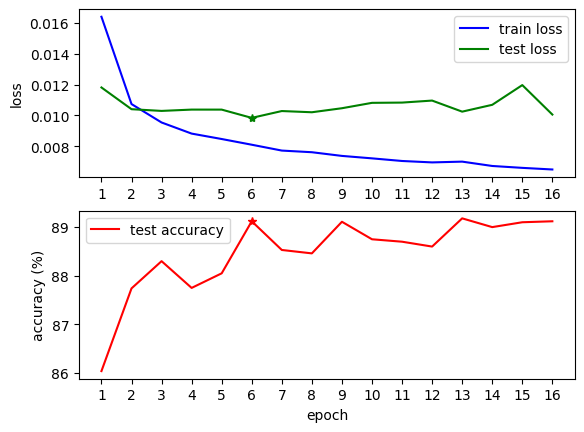

In [5]:
# train LeNet-5 (no dropout) using early stopping with patience=10
early_stop(train_dataloader, test_dataloader, model_regular, loss_fn, optimizer_regular, device, patience=10, show=True)

epoch | train_loss | test_loss | accuracy(%)
1     |   0.0197   |   0.0133  |     84.2
2     |   0.0145   |   0.0119  |     85.8
3     |   0.0134   |   0.0118  |     85.8
4     |   0.0131   |   0.0121  |     85.7
5     |   0.0128   |   0.0109  |     87.3
6     |   0.0127   |   0.0118  |     86.3
7     |   0.0126   |   0.0112  |     87.0
8     |   0.0124   |   0.0112  |     86.9
9     |   0.0123   |   0.0107  |     87.2
10    |   0.0122   |   0.0111  |     87.4
11    |   0.0122   |   0.0118  |     85.7
12    |   0.0121   |   0.0108  |     87.4
13    |   0.0119   |   0.0104  |     87.9
14    |   0.0119   |   0.0111  |     86.7
15    |   0.0118   |   0.0107  |     87.4
16    |   0.0118   |   0.0108  |     86.9
17    |   0.0119   |   0.0103  |     88.1
18    |   0.0117   |   0.0105  |     87.8
19    |   0.0118   |   0.0099  |     88.3
20    |   0.0116   |   0.0109  |     87.2
21    |   0.0118   |   0.0101  |     88.2
22    |   0.0116   |   0.0111  |     87.1
23    |   0.0117   |   0.0105  

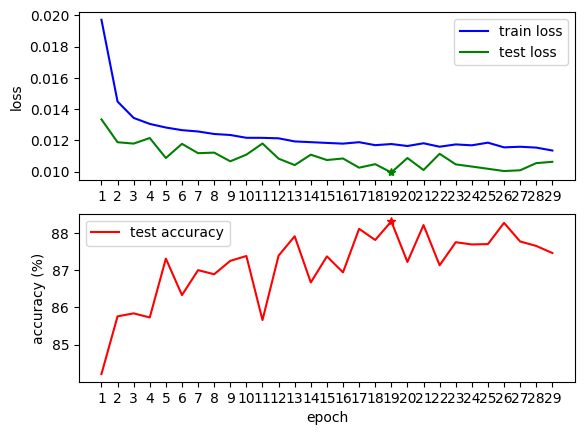

In [6]:
# train LeNet-5 (with dropout) using early stopping with patience=10
early_stop(train_dataloader, test_dataloader, model_dropout, loss_fn, optimizer_dropout, device, patience=10, show=True)